In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv('BTC-USD.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3392 entries, 0 to 3391
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       3392 non-null   object 
 1   Open       3392 non-null   float64
 2   High       3392 non-null   float64
 3   Low        3392 non-null   float64
 4   Close      3392 non-null   float64
 5   Adj Close  3392 non-null   float64
 6   Volume     3392 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 185.6+ KB


In [6]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

## Bitcoin 2013 ten günümüze kadar günlük kapanış fiyatlarının gösterilmesi

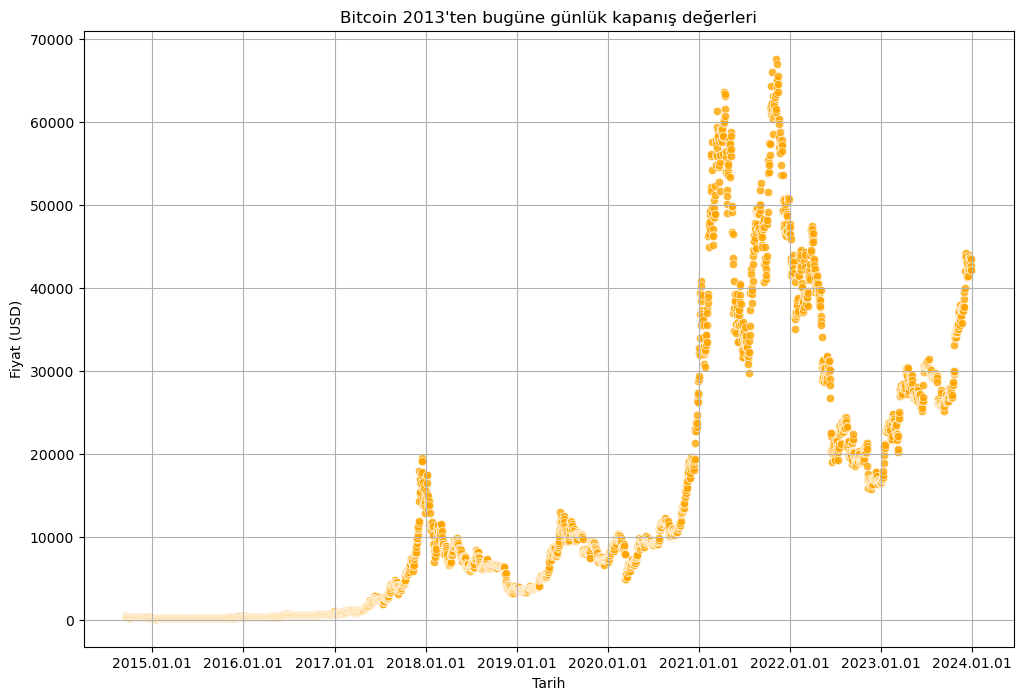

In [7]:
df['Date']  =pd.to_datetime(df['Date'])
plt.figure(figsize=(12,8))
sns.scatterplot(data=df, x='Date',y='Close',alpha=0.8,color='orange')
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y.%m.%d'))
plt.xlabel('Tarih')
plt.ylabel('Fiyat (USD)')
plt.title("Bitcoin 2013'ten bugüne günlük kapanış değerleri")
plt.grid(True)
plt.show()

<AxesSubplot:xlabel='Date'>

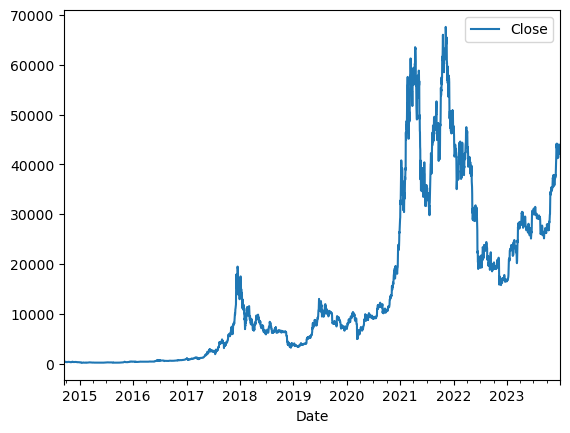

In [8]:
#Tarihe göre Kapanış miktarı
import matplotlib.pyplot as plt
df.plot(x = "Date", y = "Close")

### Bitcoinin günlük kapanış değerlerinin histogram grafiğinin çizlmesi

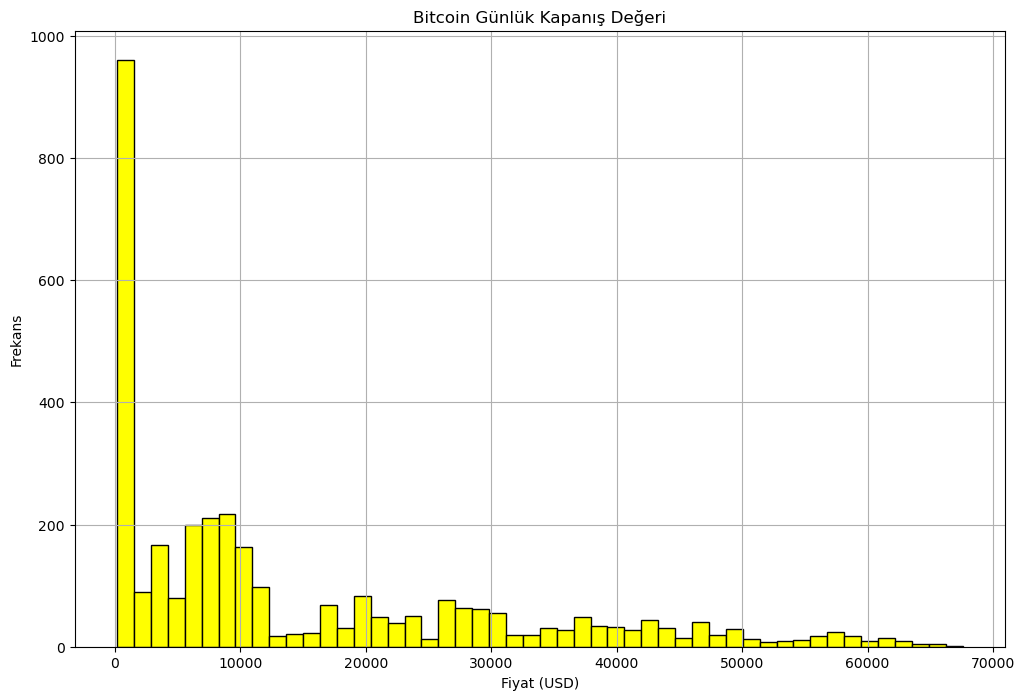

In [9]:
plt.figure(figsize=(12,8))
plt.hist(df['Close'], bins=50, edgecolor='k', color='yellow')
plt.title('Bitcoin Günlük Kapanış Değeri')
plt.xlabel('Fiyat (USD)')
plt.ylabel('Frekans')
plt.grid(True)
plt.show()


In [37]:
bitcoin_df = pd.read_csv('BTC-USD.csv')
projection_bitcoin = 14
bitcoin_df['Prediction'] = bitcoin_df[['Close']].shift(-projection_bitcoin)
X_Bitcoin = np.array(bitcoin_df[['Close']])
X_bitcoin = X_Bitcoin[:-projection_bitcoin]
print(X_Bitcoin)

[[  457.334015]
 [  424.440002]
 [  394.79599 ]
 ...
 [42627.855469]
 [42099.402344]
 [42156.902344]]


In [41]:
y_Bitcoin = bitcoin_df['Prediction'].values
y_Bitcoin = y_Bitcoin[:-projection_bitcoin]
print(y_Bitcoin)
x_train_Bitcoin, x_test_Bitcoin, y_train_Bitcoin, y_test_Bitcoin = train_test_split(X_bitcoin,y_Bitcoin,test_size=0.20)

[  383.61499    375.071991   359.511993 ... 42627.855469 42099.402344
 42156.902344]


In [42]:
# 'Tahmin'in bir sütun adı olarak mevcut olup olmadığını doğrulamak için DataFrame'inizdeki sütunların listesini yazdırın:
# print(bitcoin_df.columns) 

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Prediction'],
      dtype='object')


In [44]:
linReg_Bitcoin = LinearRegression()
linReg_Bitcoin.fit(x_train_Bitcoin,y_train_Bitcoin)
linReg_confidence_Bitcoin = linReg_Bitcoin.score(x_test_Bitcoin, y_test_Bitcoin)
print("Bitcoin için linear regresyon güvenilirliği : %", round((linReg_confidence_Bitcoin*100),3))

Bitcoin için linear regresyon güvenilirliği : % 95.703


In [45]:
x_projection_Bitcoin = np.array(bitcoin_df[['Close']])[-projection_bitcoin:]
print(x_projection_Bitcoin)

[[41364.664063]
 [42623.539063]
 [42270.527344]
 [43652.25    ]
 [43869.152344]
 [43997.902344]
 [43739.542969]
 [43016.117188]
 [43613.140625]
 [42520.402344]
 [43442.855469]
 [42627.855469]
 [42099.402344]
 [42156.902344]]


In [46]:
linReg_prediction_Bitcoin = linReg_Bitcoin.predict(x_projection_Bitcoin)
print(linReg_prediction_Bitcoin)

[41414.02850607 42664.9553996  42314.17247594 43687.17140736
 43902.7043041  44030.64142061 43773.91323839 43055.05492051
 43648.30895559 42562.46985059 43479.09892186 42669.24455329
 42144.1279007  42201.26486535]


### Tahmin edilen değerlerin grafikte gösterilmesi

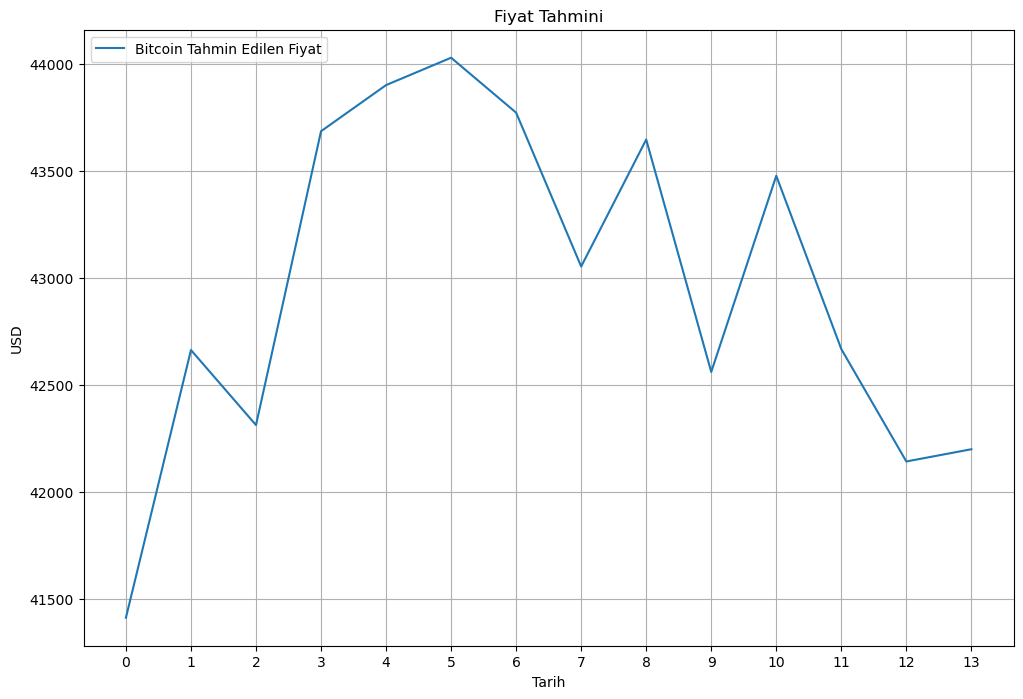

In [48]:
plt.figure(figsize=(12, 8))
plt.plot(linReg_prediction_Bitcoin, label= 'Bitcoin Tahmin Edilen Fiyat')
plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.title('Fiyat Tahmini')
plt.xlabel('Tarih')
plt.ylabel('USD')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

### Şimdi de modelimizin oluşturduğu grafik ile gerçek değerleri karşılaştıralım

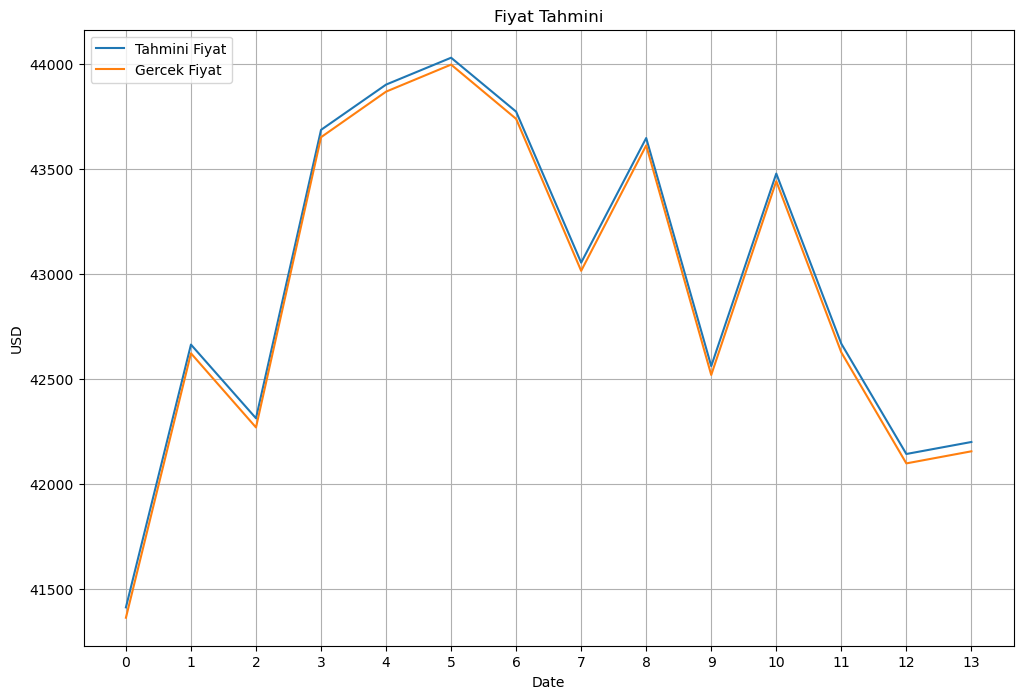

In [50]:
plt.figure(figsize=(12, 8))
plt.plot(linReg_prediction_Bitcoin, label= 'Tahmini Fiyat')
plt.plot(x_projection_Bitcoin,  label='Gercek Fiyat')
plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.title('Fiyat Tahmini')
plt.xlabel('Date')
plt.ylabel('USD')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()